In [1]:
import numpy as np
import matplotlib.pylab as plt
import time
import math

from mgdraw_output_reader_NOVO_v03 import DetectionDataStorage

primaries_per_spawn = 1.0e7
number_of_files = 100
number_of_primaries = primaries_per_spawn * number_of_files

beam_current = 2.0 # nA

In [2]:
def _load_hits(main_PATH):

    from hit_txt_file_reader_v01 import collect_txt_data

    files = {"spot1": None, "spot2": None, "spot3": None, "spot4": None, "spot5": None,
        "spot6": None, "spot7": None, "spot8": None, "spot9": None, "spot10": None}

    m = 0
    for file in files:
        m += 1

        newPath = main_PATH + rf"\Results_spot_{m}"
        print(f"Spot {m}:")

        # Importing gamma_hits
        print("Gamma hits")
        gamma_hits = np.array(collect_txt_data(newPath + rf"\gamma_hits.txt"))

        # Importing neutron_hits
        print("Neutron hits")
        neutron_hits = np.array(collect_txt_data(newPath + rf"\neutron_hits.txt"))

        files[file] = [gamma_hits, neutron_hits]

    return files

In [3]:
def load_energies(main_PATH):

    files = _load_hits(main_PATH)

    energies = {"spot1": [[], []], "spot2": [[], []], "spot3": [[], []], 
        "spot4": [[], []], "spot5": [[], []], "spot6": [[], []], "spot7": [[], []], 
        "spot8": [[], []], "spot9": [[], []], "spot10": [[], []]}
    
    regions = {"spot1": [[], []], "spot2": [[], []], "spot3": [[], []], 
        "spot4": [[], []], "spot5": [[], []], "spot6": [[], []], "spot7": [[], []], 
        "spot8": [[], []], "spot9": [[], []], "spot10": [[], []]}
    

    for file in files:
        # Loading gamma entries
        energies[file][0] = files[file][0][7]
        regions[file][0] = files[file][0][12]

        # Loading neutron entries
        energies[file][1] = files[file][1][7]
        regions[file][1] = files[file][1][12]

    return energies, regions

In [12]:
# Pediatric brain
brain_spot_energies = [120.239, 112.948, 109.551, 106.152, 99.65, 93.544, 87.635, 82.123, 76.909, 71.993]
brain_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Brain_Hv14\270_degree"
brain_hit_energies, brain_hit_regions = load_energies(brain_PATH)


# HNC
HNC_spot_energies = [134.006, 126.327, 119.041, 111.849, 105.052, 98.649, 92.643, 86.733, 81.321, 76.106]
HNC_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_HNC_05\AntObl_L_G80"
HNC_hit_energies, HNC_hit_regions = load_energies(HNC_PATH)


# Lung
lung_spot_energies = [180.740, 169.121, 158.789, 149.843, 140.982, 132.012, 123.633, 115.546, 108.051, 100.751]
lung_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Lung_04\Beam_1"
lung_hit_energies, lung_hit_regions = load_energies(lung_PATH)


# Prostate
prostate_spot_energies = [198, 195, 192, 189, 186, 183, 180, 177, 174, 171]
prostate_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Prostate_01_2field\270"
prostate_hit_energies, prostate_hit_regions = load_energies(prostate_PATH)

Spot 1:
Gamma hits
Neutron hits
Spot 2:
Gamma hits
Neutron hits
Spot 3:
Gamma hits
Neutron hits
Spot 4:
Gamma hits
Neutron hits
Spot 5:
Gamma hits
Neutron hits
Spot 6:
Gamma hits
Neutron hits
Spot 7:
Gamma hits
Neutron hits
Spot 8:
Gamma hits
Neutron hits
Spot 9:
Gamma hits
Neutron hits
Spot 10:
Gamma hits
Neutron hits
Spot 1:
Gamma hits
Neutron hits
Spot 2:
Gamma hits
Neutron hits
Spot 3:
Gamma hits
Neutron hits
Spot 4:
Gamma hits
Neutron hits
Spot 5:
Gamma hits
Neutron hits
Spot 6:
Gamma hits
Neutron hits
Spot 7:
Gamma hits
Neutron hits
Spot 8:
Gamma hits
Neutron hits
Spot 9:
Gamma hits
Neutron hits
Spot 10:
Gamma hits
Neutron hits
Spot 1:
Gamma hits
Neutron hits
Spot 2:
Gamma hits
Neutron hits
Spot 3:
Gamma hits
Neutron hits
Spot 4:
Gamma hits
Neutron hits
Spot 5:
Gamma hits
Neutron hits
Spot 6:
Gamma hits
Neutron hits
Spot 7:
Gamma hits
Neutron hits
Spot 8:
Gamma hits
Neutron hits
Spot 9:
Gamma hits
Neutron hits
Spot 10:
Gamma hits
Neutron hits
Spot 1:
Gamma hits
Neutron hits
Spot 

Text(0, 0.5, 'Counts')

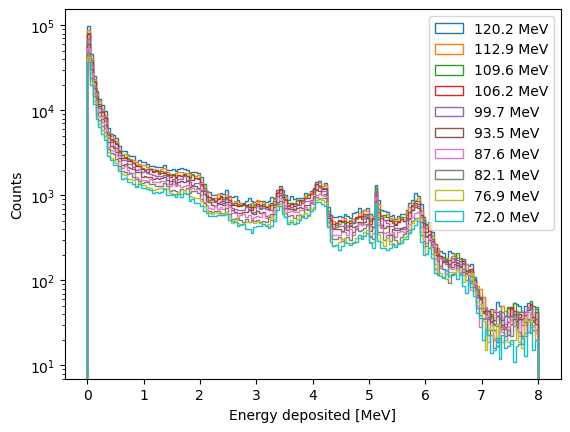

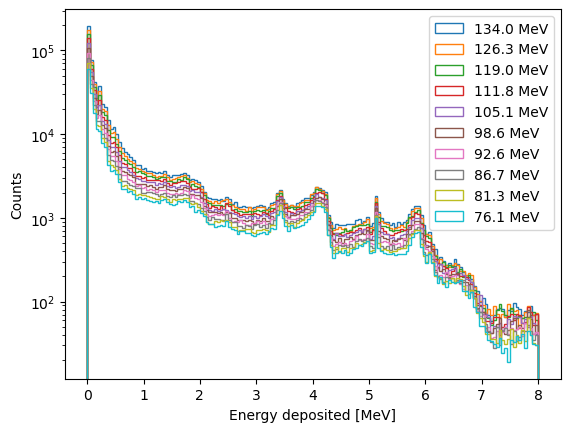

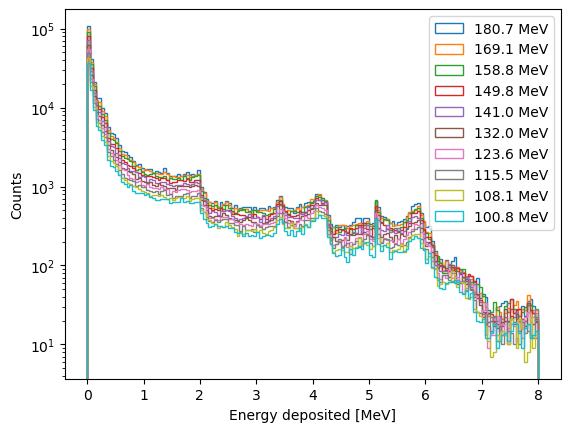

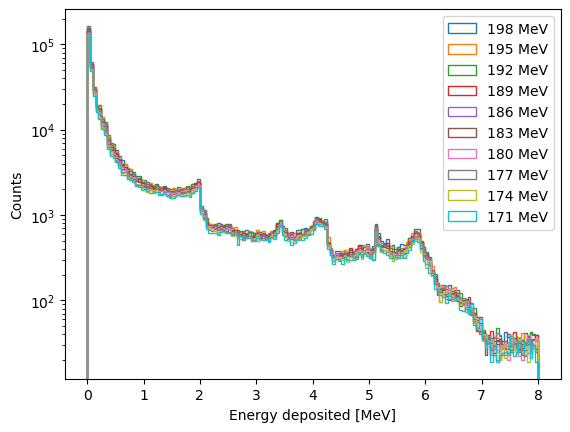

In [21]:
# Brain-------------------------------------------------------------------
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]
plt.figure()

m = -1
for spot in brain_hit_energies:
    m += 1
    plt.hist(brain_hit_energies[spot][0], bins=bins, histtype="step", label=f"{round(brain_spot_energies[m], 1)} MeV", density=False)

plt.legend()
plt.yscale("log")
plt.xlabel("Energy deposited [MeV]")
plt.ylabel("Counts")


# HNC-------------------------------------------------------------------
plt.figure()

m = -1
for spot in HNC_hit_energies:
    m += 1
    plt.hist(HNC_hit_energies[spot][0], bins=bins, histtype="step", label=f"{round(HNC_spot_energies[m], 1)} MeV", density=False)

plt.legend()
plt.yscale("log")
plt.xlabel("Energy deposited [MeV]")
plt.ylabel("Counts")


# Lung-------------------------------------------------------------------
plt.figure()

m = -1
for spot in lung_hit_energies:
    m += 1
    plt.hist(lung_hit_energies[spot][0], bins=bins, histtype="step", label=f"{round(lung_spot_energies[m], 1)} MeV", density=False)

plt.legend()
plt.yscale("log")
plt.xlabel("Energy deposited [MeV]")
plt.ylabel("Counts")


# Prostate-------------------------------------------------------------------
plt.figure()

m = -1
for spot in prostate_hit_energies:
    m += 1
    plt.hist(prostate_hit_energies[spot][0], bins=bins, histtype="step", label=f"{round(prostate_spot_energies[m], 1)} MeV", density=False)

plt.legend()
plt.yscale("log")
plt.xlabel("Energy deposited [MeV]")
plt.ylabel("Counts")


In [14]:
tot_hit_energies_g = []
tot_hit_energies_n = []

patients = [brain_hit_energies, HNC_hit_energies, lung_hit_energies, prostate_hit_energies]

for patient in patients:
    gamma_hit_energies_burner = []
    neutron_hit_energies_burner = []

    for spot in brain_hit_energies:

        gamma_hit_energies_burner.append(patient[spot][0])
        neutron_hit_energies_burner.append(patient[spot][1])

    gamma_hit_energies_burner = np.concatenate(np.array(gamma_hit_energies_burner, dtype=object))
    neutron_hit_energies_burner = np.concatenate(np.array(neutron_hit_energies_burner, dtype=object))

    tot_hit_energies_g.append(gamma_hit_energies_burner)
    tot_hit_energies_n.append(neutron_hit_energies_burner)

Text(0, 0.5, 'Normalized counts [a.u.]')

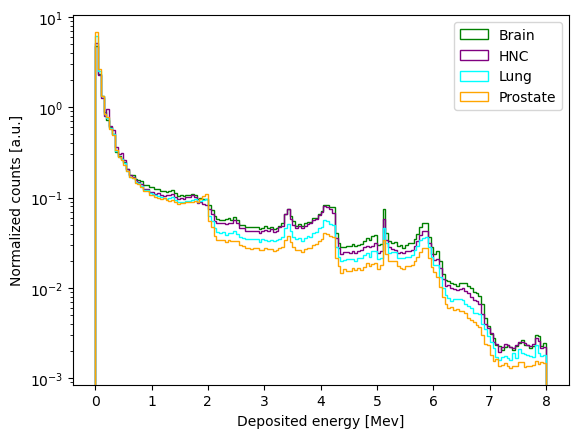

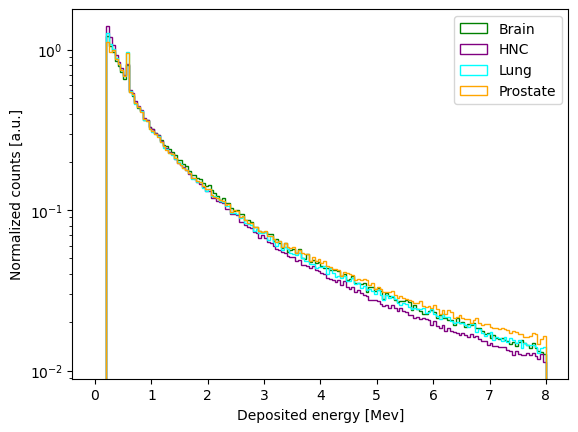

In [15]:
# Gammas
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

m = -1
pats = ["Brain", "HNC", "Lung", "Prostate"]
pat_clrs = ["green", "purple", "cyan", "orange"]
for pat in tot_hit_energies_g:
    m += 1
    plt.hist(pat, bins=bins, histtype="step", label=pats[m], density=True, color=pat_clrs[m])
plt.yscale("log")

plt.xlabel("Deposited energy [Mev]")
plt.ylabel("Normalized counts [a.u.]")

CE1 = 1.99  # MeV
CE2 = 4.24  # MeV
CE3 = 5.88  # MeV
DEPP1 = 3.44    # MeV
DEPP2 = 5.14    # MeV

def calc_energy_from_Compton_edge(CE):
    return round(0.5 * CE * (1 + math.sqrt(1 + 2 * (0.511 / CE))), 2)

# Plotting lines
#plt.axvline(CE1, ls="--", color="gray", label=f"{CE1}/ {calc_energy_from_Compton_edge(CE1)} MeV")    # 2.00 MeV Compton edge (2.22 MeV)
#plt.axvline(CE2, ls="--", color="gray", label=f"{CE2}/ {calc_energy_from_Compton_edge(CE2)} MeV")    # 4.24 MeV Compton edge (4.44 MeV)
#plt.axvline(CE3, ls="--", color="gray", label=f"{CE3}/ {calc_energy_from_Compton_edge(CE3)} MeV")    # 5.88 MeV Compton edge (6.13 MeV)
#plt.axvline(DEPP1, ls="--", color="gray", label=f"{DEPP1}/ {round(DEPP1 + 2 * 0.511, 2)} MeV")    # 3.44 MeV Double escape photopeak (4.44 MeV)
#plt.axvline(DEPP2, ls="--", color="gray", label=f"{DEPP2}/ {round(DEPP2 + 2 * 0.511, 2)} MeV")    # 5.14 MeV Double escape photopeak (6.13 MeV)

#plt.axvline(DEPP3, ls="--", color="gray", label=f"{DEPP3} MeV")

plt.legend()

# Neutrons
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

plt.figure()
m = -1
pats = ["Brain", "HNC", "Lung", "Prostate"]
pat_clrs = ["green", "purple", "cyan", "orange"]
for pat in tot_hit_energies_n:
    m += 1
    plt.hist(pat, bins=bins, histtype="step", label=pats[m], density=True, color=pat_clrs[m])
plt.yscale("log")
plt.legend()

plt.xlabel("Deposited energy [Mev]")
plt.ylabel("Normalized counts [a.u.]")


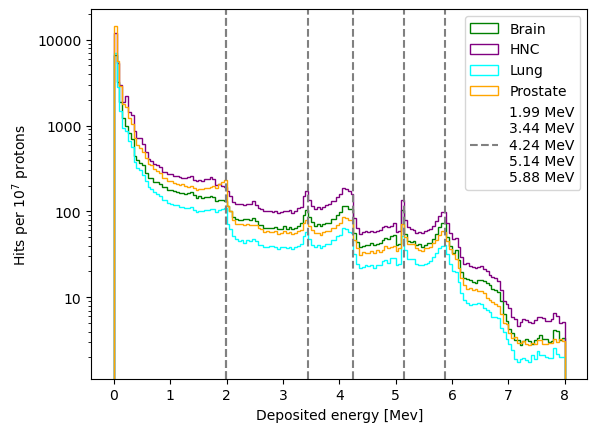

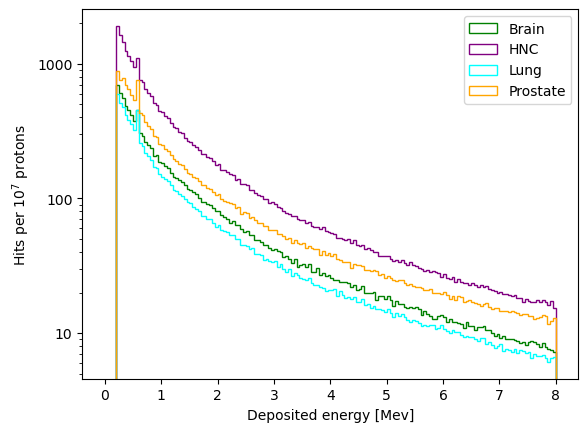

In [16]:
# Gammas
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]


m = -1
pats = ["Brain", "HNC", "Lung", "Prostate"]
pat_clrs = ["green", "purple", "cyan", "orange"]
for pat in tot_hit_energies_g:
    m += 1
    plt.hist(pat, bins=bins, histtype="step", label=pats[m], color=pat_clrs[m])
plt.yscale("log")

plt.xlabel("Deposited energy [Mev]")
plt.ylabel("Hits per $10^7$ protons")

CE1 = 1.99  # MeV
CE2 = 4.24  # MeV
CE3 = 5.88  # MeV
DEPP1 = 3.44    # MeV
DEPP2 = 5.14    # MeV

def calc_energy_from_Compton_edge(CE):
    return round(0.5 * CE * (1 + math.sqrt(1 + 2 * (0.511 / CE))), 2)

# Plotting lines
plt.axvline(CE1, ls="--", color="gray", label=f"{CE1} MeV\n{DEPP1} MeV\n{CE2} MeV\n{DEPP2} MeV\n{CE3} MeV")
plt.axvline(CE1, ls="--", color="gray")#, label=f"{CE1}: PG {calc_energy_from_Compton_edge(CE1)} MeV")    # 2.00 MeV Compton edge (2.22 MeV)
plt.axvline(CE2, ls="--", color="gray")#, label=f"{CE2}: PG {calc_energy_from_Compton_edge(CE2)} MeV")    # 4.24 MeV Compton edge (4.44 MeV)
plt.axvline(CE3, ls="--", color="gray")#, label=f"{CE3}: PG {calc_energy_from_Compton_edge(CE3)} MeV")    # 5.88 MeV Compton edge (6.13 MeV)
plt.axvline(DEPP1, ls="--", color="gray")#, label=f"{DEPP1}: PG {round(DEPP1 + 2 * 0.511, 2)} MeV")    # 3.44 MeV Double escape photopeak (4.44 MeV)
plt.axvline(DEPP2, ls="--", color="gray")#, label=f"{DEPP2}: PG {round(DEPP2 + 2 * 0.511, 2)} MeV")    # 5.14 MeV Double escape photopeak (6.13 MeV)

#plt.axvline(DEPP3, ls="--", color="gray", label=f"{DEPP3} MeV")

plt.legend()


import matplotlib.ticker as ticker
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f'{y/100:g}')
)

# Neutrons
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

plt.figure()
m = -1
pats = ["Brain", "HNC", "Lung", "Prostate"]
pat_clrs = ["green", "purple", "cyan", "orange"]
for pat in tot_hit_energies_n:
    m += 1
    plt.hist(pat, bins=bins, histtype="step", label=pats[m], color=pat_clrs[m])
plt.yscale("log")
plt.legend()

plt.xlabel("Deposited energy [Mev]")
plt.ylabel("Hits per $10^7$ protons")


import matplotlib.ticker as ticker
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f'{y/100:g}')
)

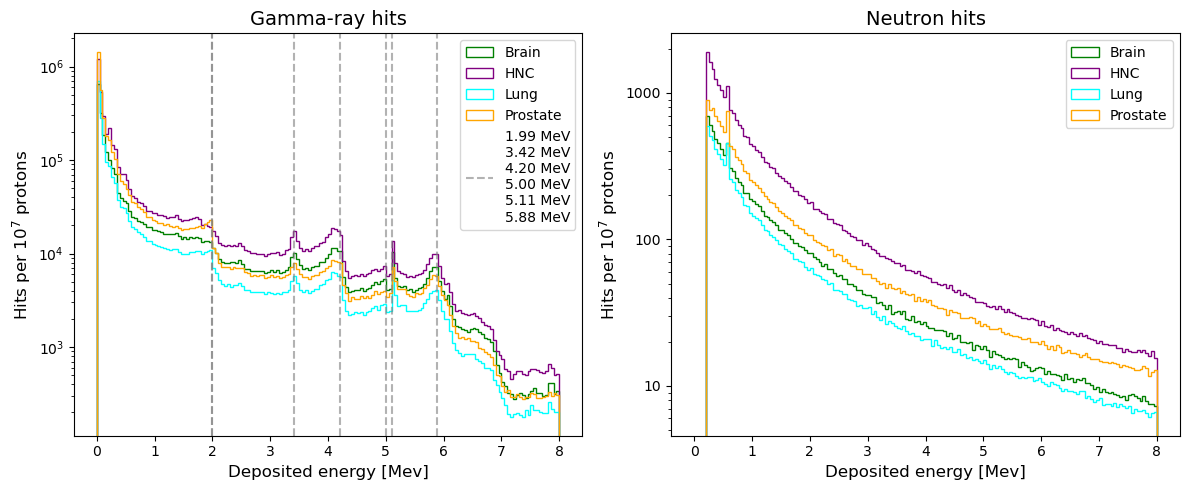

In [17]:
# Putting stuff in the same figure
# Gammas
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

m = -1
pats = ["Brain", "HNC", "Lung", "Prostate"]
pat_clrs = ["green", "purple", "cyan", "orange"]
for pat in tot_hit_energies_g:
    m += 1
    axs[0].hist(pat, bins=bins, histtype="step", label=pats[m], color=pat_clrs[m])
axs[0].set_yscale("log")

axs[0].set_xlabel("Deposited energy [Mev]", size=12)
axs[0].set_ylabel("Hits per $10^7$ protons", size=12)
axs[0].set_title("Gamma-ray hits", size=14)

CE1 = 1.99  # MeV
CE2 = 4.20  # MeV
CE3 = 5.88  # MeV
CE4 = 5.0  # MeV
DEPP1 = 3.42    # MeV
DEPP2 = 5.11    # MeV


def calc_energy_from_Compton_edge(CE):
    return round(0.5 * CE * (1 + math.sqrt(1 + 2 * (0.511 / CE))), 2)

alfa = 0.6
# Plotting lines
axs[0].axvline(CE1, ls="--", color="gray", alpha=alfa, 
               label=
               f"{CE1} MeV" +# ({calc_energy_from_Compton_edge(CE1)} MeV)" + 
               f"\n{DEPP1} MeV" +# ({round(DEPP1 + 2 * 0.511, 2)} MeV)" + 
               f"\n{CE2}0 MeV" +# ({calc_energy_from_Compton_edge(CE2)} MeV)" + 
               f"\n{CE4}0 MeV" +# ({calc_energy_from_Compton_edge(CE4)} MeV)" + 
               f"\n{DEPP2} MeV" +# ({round(DEPP2 + 2 * 0.511, 2)} MeV)" + 
               f"\n{CE3} MeV"# ({calc_energy_from_Compton_edge(CE3)} MeV)"
               )
axs[0].axvline(CE1, ls="--", color="gray", alpha=alfa)#, label=f"{CE1}: PG {calc_energy_from_Compton_edge(CE1)} MeV")    # 2.00 MeV Compton edge (2.22 MeV)
axs[0].axvline(CE2, ls="--", color="gray", alpha=alfa)#, label=f"{CE2}: PG {calc_energy_from_Compton_edge(CE2)} MeV")    # 4.24 MeV Compton edge (4.44 MeV)
axs[0].axvline(CE3, ls="--", color="gray", alpha=alfa)#, label=f"{CE3}: PG {calc_energy_from_Compton_edge(CE3)} MeV")    # 5.88 MeV Compton edge (6.13 MeV)
axs[0].axvline(DEPP1, ls="--", color="gray", alpha=alfa)#, label=f"{DEPP1}: PG {round(DEPP1 + 2 * 0.511, 2)} MeV")    # 3.44 MeV Double escape photopeak (4.44 MeV)
axs[0].axvline(DEPP2, ls="--", color="gray", alpha=alfa)#, label=f"{DEPP2}: PG {round(DEPP2 + 2 * 0.511, 2)} MeV")    # 5.14 MeV Double escape photopeak (6.13 MeV)

axs[0].axvline(CE4, ls="--", color="gray", alpha=alfa)  # 5.02 MeV Compton edge

#plt.axvline(DEPP3, ls="--", color="gray", label=f"{DEPP3} MeV")

axs[0].legend()


import matplotlib.ticker as ticker
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f'{y/100:g}')
)

# Neutrons
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

plt.subplot(1, 2, 2)
#plt.figure()
m = -1
pats = ["Brain", "HNC", "Lung", "Prostate"]
pat_clrs = ["green", "purple", "cyan", "orange"]
for pat in tot_hit_energies_n:
    m += 1
    axs[1].hist(pat, bins=bins, histtype="step", label=pats[m], color=pat_clrs[m])
axs[1].set_yscale("log")
axs[1].legend()

axs[1].set_xlabel("Deposited energy [Mev]", size=12)
axs[1].set_ylabel("Hits per $10^7$ protons", size=12)
axs[1].set_title("Neutron hits", size=14)


import matplotlib.ticker as ticker
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f'{y/100:g}')
)


plt.tight_layout()

For only one spot:

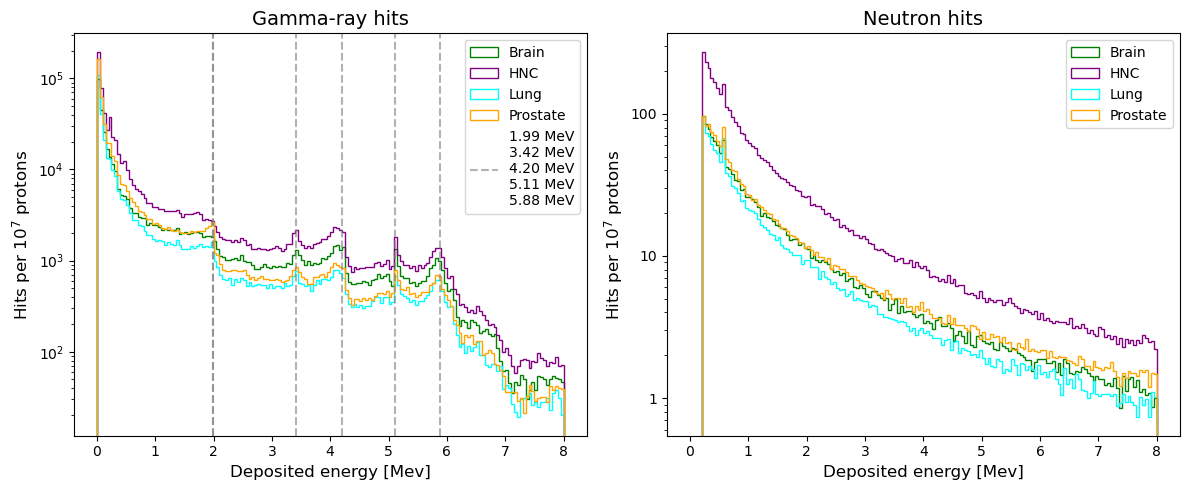

In [24]:
# Putting stuff in the same figure
# Gammas
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

selected_spot = "spot1"
patient_hit_energies = [brain_hit_energies[selected_spot], HNC_hit_energies[selected_spot], lung_hit_energies[selected_spot], prostate_hit_energies[selected_spot]]

m = -1
pats = ["Brain", "HNC", "Lung", "Prostate"]
pat_clrs = ["green", "purple", "cyan", "orange"]
for pat in patient_hit_energies:
    m += 1
    axs[0].hist(pat[0], bins=bins, histtype="step", label=pats[m], color=pat_clrs[m])
axs[0].set_yscale("log")

axs[0].set_xlabel("Deposited energy [Mev]", size=12)
axs[0].set_ylabel("Hits per $10^7$ protons", size=12)
axs[0].set_title("Gamma-ray hits", size=14)

CE1 = 1.99  # MeV
CE2 = 4.20  # MeV
CE3 = 5.88  # MeV
CE4 = 5.0  # MeV
DEPP1 = 3.42    # MeV
DEPP2 = 5.11    # MeV


def calc_energy_from_Compton_edge(CE):
    return round(0.5 * CE * (1 + math.sqrt(1 + 2 * (0.511 / CE))), 2)

alfa = 0.6
# Plotting lines
axs[0].axvline(CE1, ls="--", color="gray", alpha=alfa, 
               label=
               f"{CE1} MeV" +# ({calc_energy_from_Compton_edge(CE1)} MeV)" + 
               f"\n{DEPP1} MeV" +# ({round(DEPP1 + 2 * 0.511, 2)} MeV)" + 
               f"\n{CE2}0 MeV" +# ({calc_energy_from_Compton_edge(CE2)} MeV)" + 
               f"\n{DEPP2} MeV" +# ({round(DEPP2 + 2 * 0.511, 2)} MeV)" + 
               f"\n{CE3} MeV"# ({calc_energy_from_Compton_edge(CE3)} MeV)"
               )
axs[0].axvline(CE1, ls="--", color="gray", alpha=alfa)#, label=f"{CE1}: PG {calc_energy_from_Compton_edge(CE1)} MeV")    # 2.00 MeV Compton edge (2.22 MeV)
axs[0].axvline(CE2, ls="--", color="gray", alpha=alfa)#, label=f"{CE2}: PG {calc_energy_from_Compton_edge(CE2)} MeV")    # 4.24 MeV Compton edge (4.44 MeV)
axs[0].axvline(CE3, ls="--", color="gray", alpha=alfa)#, label=f"{CE3}: PG {calc_energy_from_Compton_edge(CE3)} MeV")    # 5.88 MeV Compton edge (6.13 MeV)
axs[0].axvline(DEPP1, ls="--", color="gray", alpha=alfa)#, label=f"{DEPP1}: PG {round(DEPP1 + 2 * 0.511, 2)} MeV")    # 3.44 MeV Double escape photopeak (4.44 MeV)
axs[0].axvline(DEPP2, ls="--", color="gray", alpha=alfa)#, label=f"{DEPP2}: PG {round(DEPP2 + 2 * 0.511, 2)} MeV")    # 5.14 MeV Double escape photopeak (6.13 MeV)

#axs[0].axvline(CE4, ls="--", color="gray", alpha=alfa)  # 5.02 MeV Compton edge

#plt.axvline(DEPP3, ls="--", color="gray", label=f"{DEPP3} MeV")

axs[0].legend()


import matplotlib.ticker as ticker
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f'{y/100:g}')
)

# Neutrons
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

plt.subplot(1, 2, 2)
#plt.figure()
m = -1
pats = ["Brain", "HNC", "Lung", "Prostate"]
pat_clrs = ["green", "purple", "cyan", "orange"]
for pat in patient_hit_energies:
    m += 1
    axs[1].hist(pat[1], bins=bins, histtype="step", label=pats[m], color=pat_clrs[m])
axs[1].set_yscale("log")
axs[1].legend()

axs[1].set_xlabel("Deposited energy [Mev]", size=12)
axs[1].set_ylabel("Hits per $10^7$ protons", size=12)
axs[1].set_title("Neutron hits", size=14)


import matplotlib.ticker as ticker
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f'{y/100:g}')
)


plt.tight_layout()

Checking energy specter from different layers

386874
706672


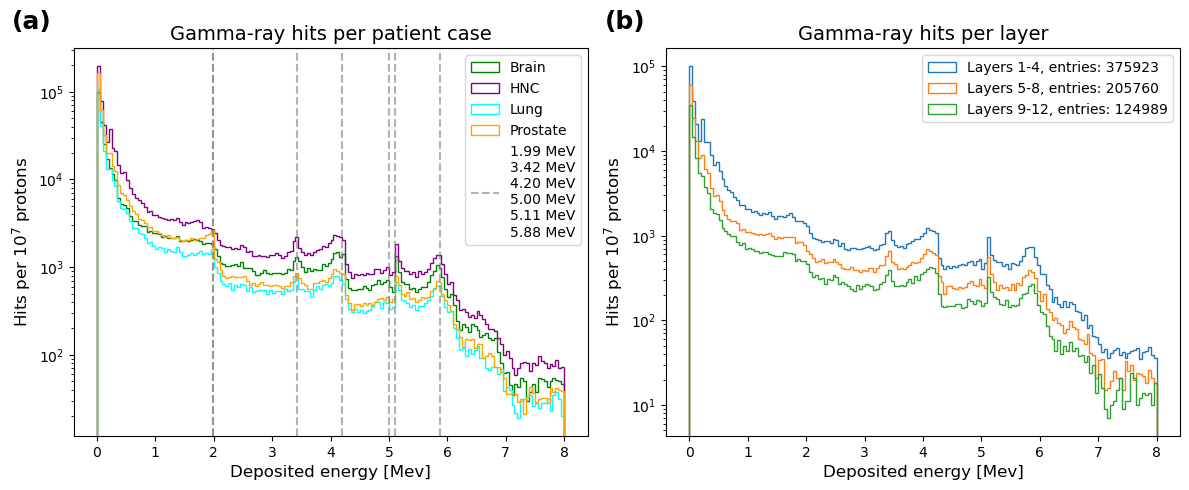

In [ ]:
# Putting stuff in the same figure
# Gammas
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
selected_spot = "spot1"
patient_hit_energies = [brain_hit_energies[selected_spot], HNC_hit_energies[selected_spot], lung_hit_energies[selected_spot], prostate_hit_energies[selected_spot]]

m = -1
pats = ["Brain", "HNC", "Lung", "Prostate"]
pat_clrs = ["green", "purple", "cyan", "orange"]
for pat in patient_hit_energies:
    m += 1
    axs[0].hist(pat[0], bins=bins, histtype="step", label=pats[m], color=pat_clrs[m])
axs[0].set_yscale("log")

axs[0].set_xlabel("Deposited energy [Mev]", size=12)
axs[0].set_ylabel("Hits per $10^7$ protons", size=12)
axs[0].set_title("Gamma-ray hits per patient case", size=14)

CE1 = 1.99  # MeV
CE2 = 4.20  # MeV
CE3 = 5.88  # MeV
CE4 = 5.0  # MeV
DEPP1 = 3.42    # MeV
DEPP2 = 5.11    # MeV

def calc_energy_from_Compton_edge(CE):
    return round(0.5 * CE * (1 + math.sqrt(1 + 2 * (0.511 / CE))), 2)

alfa = 0.6
# Plotting lines
axs[0].axvline(CE1, ls="--", color="gray", alpha=alfa, 
               label=
               f"{CE1} MeV" +# ({calc_energy_from_Compton_edge(CE1)} MeV)" + 
               f"\n{DEPP1} MeV" +# ({round(DEPP1 + 2 * 0.511, 2)} MeV)" + 
               f"\n{CE2}0 MeV" +# ({calc_energy_from_Compton_edge(CE2)} MeV)" + 
               f"\n{CE4}0 MeV" +# ({calc_energy_from_Compton_edge(CE4)} MeV)" + 
               f"\n{DEPP2} MeV" +# ({round(DEPP2 + 2 * 0.511, 2)} MeV)" + 
               f"\n{CE3} MeV"# ({calc_energy_from_Compton_edge(CE3)} MeV)"
               )
axs[0].axvline(CE1, ls="--", color="gray", alpha=alfa)#, label=f"{CE1}: PG {calc_energy_from_Compton_edge(CE1)} MeV")    # 2.00 MeV Compton edge (2.22 MeV)
axs[0].axvline(CE2, ls="--", color="gray", alpha=alfa)#, label=f"{CE2}: PG {calc_energy_from_Compton_edge(CE2)} MeV")    # 4.24 MeV Compton edge (4.44 MeV)
axs[0].axvline(CE3, ls="--", color="gray", alpha=alfa)#, label=f"{CE3}: PG {calc_energy_from_Compton_edge(CE3)} MeV")    # 5.88 MeV Compton edge (6.13 MeV)
axs[0].axvline(DEPP1, ls="--", color="gray", alpha=alfa)#, label=f"{DEPP1}: PG {round(DEPP1 + 2 * 0.511, 2)} MeV")    # 3.44 MeV Double escape photopeak (4.44 MeV)
axs[0].axvline(DEPP2, ls="--", color="gray", alpha=alfa)#, label=f"{DEPP2}: PG {round(DEPP2 + 2 * 0.511, 2)} MeV")    # 5.14 MeV Double escape photopeak (6.13 MeV)

axs[0].axvline(CE4, ls="--", color="gray", alpha=alfa)  # 5.02 MeV Compton edge

#plt.axvline(DEPP3, ls="--", color="gray", label=f"{DEPP3} MeV")

axs[0].legend()
import matplotlib.ticker as ticker
axs[0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f'{y/100:g}')
)

# Gamma per layer
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]



region_bin_gamma_counts = []

patient_hit_regions = [brain_hit_regions[selected_spot], HNC_hit_regions[selected_spot], lung_hit_regions[selected_spot], prostate_hit_regions[selected_spot]]

for pat_hits, pat_regions in zip(patient_hit_energies, patient_hit_regions):

    region_bin_width = 16    # 1 - 4, 5 - 8, 9 - 12
    num_region_bins = int(48 / region_bin_width)
    lower_region_edge = 1
    higher_region_edge = region_bin_width
    gamma_region_counts_burner = []

    for region_bin in range(num_region_bins):

        
        # Make mask of regions that are between 1-4, 5-8, 9-12
        pat_region_mask = (pat_regions[0] >= lower_region_edge) & (pat_regions[0] <= higher_region_edge)

        # Only pick out the hits that correspond to these regions
        pat_region_hits = pat_hits[0][pat_region_mask]
    
        # Build hits per layer list
        gamma_region_counts_burner.append(pat_region_hits)

            # Increase the bin edges
        lower_region_edge += region_bin_width
        higher_region_edge += region_bin_width

    region_bin_gamma_counts.append(gamma_region_counts_burner)

linestyles = ["solid", "dashed", "dotted", "dashdot"]
m = 1
for region_bin_counts in region_bin_gamma_counts[1]:    # Brain pat
    
    axs[1].hist(region_bin_counts, bins=bins, histtype="step", label=f"Layers {4 * m - 3}-{4 * m}, entries: {round(len(region_bin_counts))}")
    m += 1

axs[1].set_yscale("log")

axs[1].set_xlabel("Deposited energy [Mev]", size=12)
axs[1].set_ylabel("Hits per $10^7$ protons", size=12)
axs[1].set_title("Gamma-ray hits per layer", size=14)

axs[1].legend()

print(len(brain_hit_energies[selected_spot][0]))
print(len(region_bin_gamma_counts[1][0]) + len(region_bin_gamma_counts[1][1]) + len(region_bin_gamma_counts[1][2]))


# Extra text


for ax, label in zip(axs, ["(a)", "(b)"]):
    ax.text(
        -0.12, 1.05, label,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold"
    )


plt.tight_layout()

Text(0, 0.5, 'Counts')

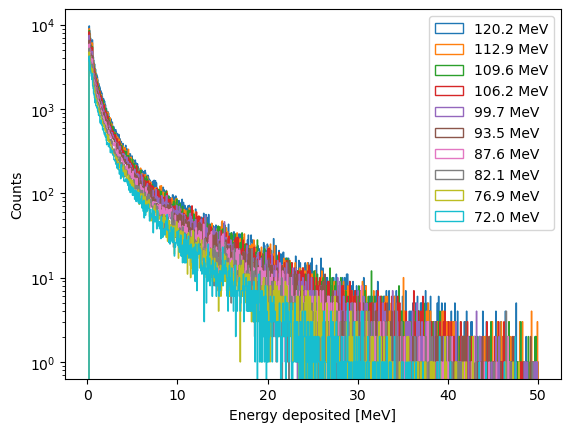

In [20]:

bin_width = 0.05     # MeV
max_energy = 50   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]
plt.figure()
m = -1
for spot in brain_hit_energies:
    m += 1
    plt.hist(brain_hit_energies[spot][1], bins=bins, histtype="step", label=f"{round(brain_spot_energies[m], 1)} MeV")

plt.legend()
plt.yscale("log")
plt.xlabel("Energy deposited [MeV]")
plt.ylabel("Counts")